In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/1st dataset.zip'
extract_path = '/content/bone_data'

os.makedirs(extract_path, exist_ok=True)

!unzip -o "{zip_path}" -d "{extract_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotat

In [ ]:
dataset_path = '/content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + '/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    dataset_path + '/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_generator.num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.000001
)

In [16]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 632s 2s/step - accuracy: 0.9705 - loss: 0.0773 - val_accuracy: 0.9590 - val_loss: 0.0987 - learning_rate: 1.0000e-04
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.9749 - loss: 0.0714 - val_accuracy: 0.9650 - val_loss: 0.1031 - learning_rate: 1.0000e-04
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.9748 - loss: 0.0697 - val_accuracy: 0.9650 - val_loss: 0.0975 - learning_rate: 1.0000e-04
Epoch 4/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 639s 2s/step - accuracy: 0.9742 - loss: 0.0740 - val_accuracy: 0.9662 - val_loss: 0.1008 - learning_rate: 1.0000e-04
Epoch 5/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 616s 2s/step - accuracy: 0.9798 - loss: 0.0629 - val_accuracy: 0.9638 - val_loss: 0.1011 - learning_rate: 1.0000e-04
Epoch 6/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 625s 2s/step - accuracy: 0.9820 - loss: 0.0494 - val_accuracy: 0.9662 - val_loss: 0.0886 - learning_rate: 2.0000e-05
Epoch 7/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - acc

In [17]:
model.save('/content/drive/MyDrive/final_bone_fracture_model.keras')

print('Model Saved Successfully!')

Model Saved Successfully!


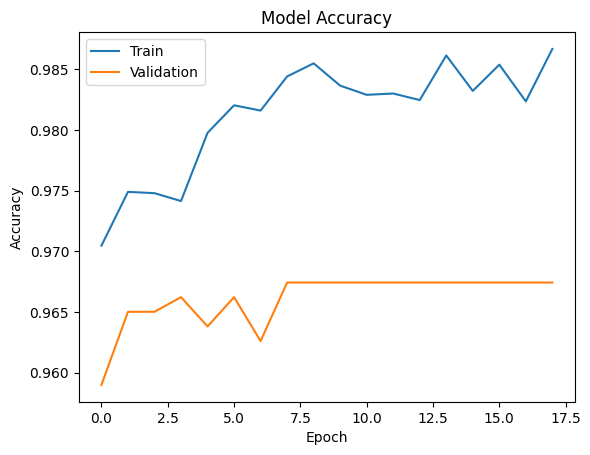

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()

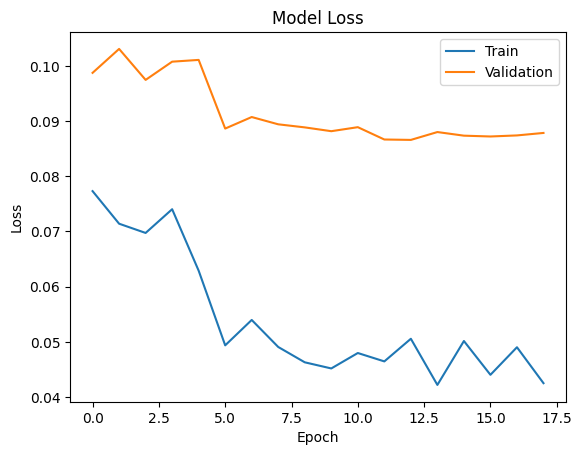

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()

In [20]:
loss, accuracy = model.evaluate(validation_generator)

print('Validation Loss:', loss)
print('Validation Accuracy:', accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9674 - loss: 0.0866
Validation Loss: 0.08658543974161148
Validation Accuracy: 0.9674306511878967


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

Y_pred = model.predict(validation_generator)

y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred)

print(cm)

26/26 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step
[[318  19]
 [  8 484]]


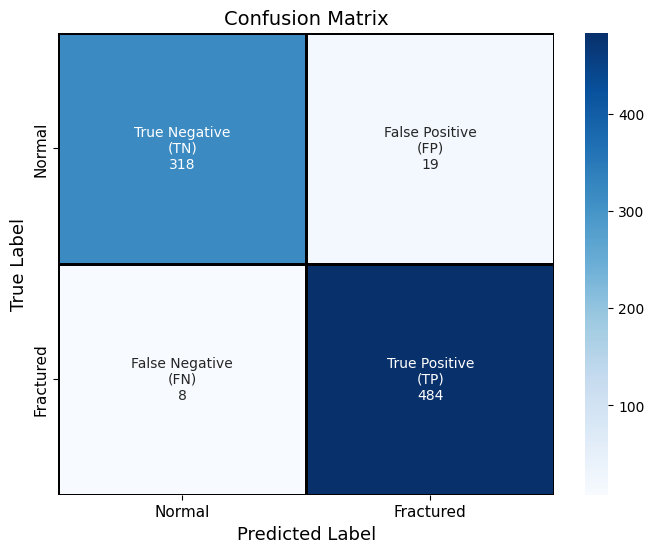

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion Matrix Values
cm = np.array([[318, 19],
               [8, 484]])

# Labels for each box
labels = np.array([
    ['True Negative\n(TN)\n318', 'False Positive\n(FP)\n19'],
    ['False Negative\n(FN)\n8', 'True Positive\n(TP)\n484']
])

# Plot Size
plt.figure(figsize=(8,6))

# Heatmap
sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    cbar=True,
    linewidths=2,
    linecolor='black',
    xticklabels=['Normal', 'Fractured'],
    yticklabels=['Normal', 'Fractured']
)

# Titles and Labels
plt.title('Confusion Matrix', fontsize=14)

plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

In [22]:
class_names = list(train_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

               precision    recall  f1-score   support

    fractured       0.98      0.94      0.96       337
not fractured       0.96      0.98      0.97       492

     accuracy                           0.97       829
    macro avg       0.97      0.96      0.97       829
 weighted avg       0.97      0.97      0.97       829



Saving 222.jpg to 222 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


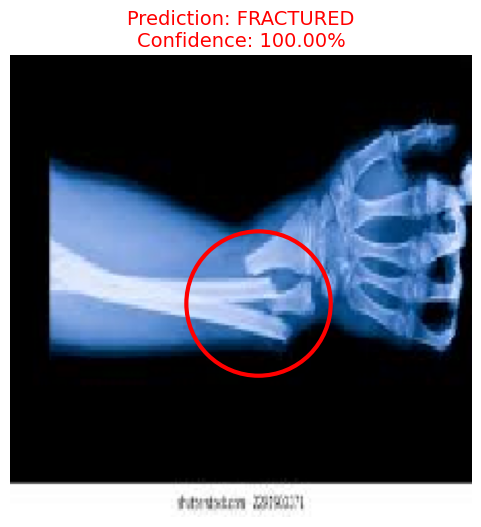

In [43]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array_norm = img_array / 255.0

# Expand dimensions
img_array_norm = np.expand_dims(img_array_norm, axis=0)

# Predict
prediction = model.predict(img_array_norm)

# Confidence
confidence = np.max(prediction) * 100

# Class names
class_names = list(train_generator.class_indices.keys())

# Prediction label
predicted_class = class_names[np.argmax(prediction)]

# Display image
fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(img)

# Add circle if fractured predicted
if predicted_class.lower() == 'fractured':

    circle = patches.Circle(
        (120,120),   # x,y position
        35,          # radius
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(circle)

    plt.title(
        f'Prediction: FRACTURED\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='red'
    )

else:

    plt.title(
        f'Prediction: NORMAL\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='green'
    )

plt.axis('off')
plt.show()

Saving 1111.jpg to 1111 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


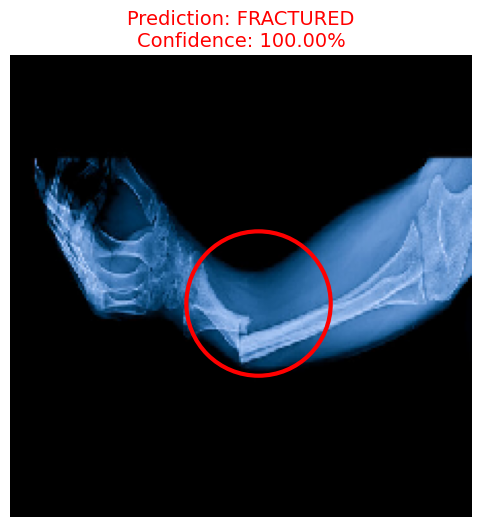

In [45]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array_norm = img_array / 255.0

# Expand dimensions
img_array_norm = np.expand_dims(img_array_norm, axis=0)

# Predict
prediction = model.predict(img_array_norm)

# Confidence
confidence = np.max(prediction) * 100

# Class names
class_names = list(train_generator.class_indices.keys())

# Prediction label
predicted_class = class_names[np.argmax(prediction)]

# Display image
fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(img)

# Add circle if fractured predicted
if predicted_class.lower() == 'fractured':

    circle = patches.Circle(
        (120,120),   # x,y position
        35,          # radius
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(circle)

    plt.title(
        f'Prediction: FRACTURED\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='red'
    )

else:

    plt.title(
        f'Prediction: NORMAL\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='green'
    )

plt.axis('off')
plt.show()

Saving hand.jpg to hand (4).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


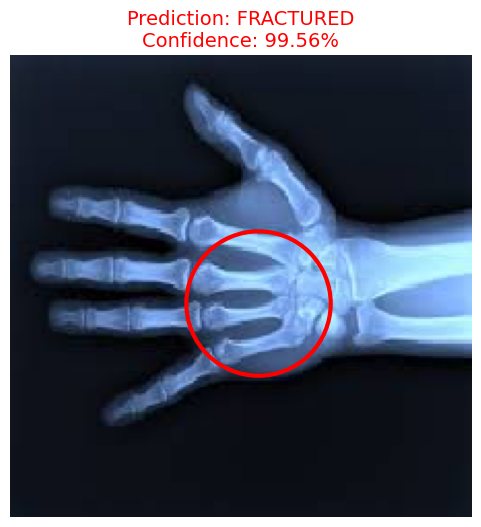

In [46]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array_norm = img_array / 255.0

# Expand dimensions
img_array_norm = np.expand_dims(img_array_norm, axis=0)

# Predict
prediction = model.predict(img_array_norm)

# Confidence
confidence = np.max(prediction) * 100

# Class names
class_names = list(train_generator.class_indices.keys())

# Prediction label
predicted_class = class_names[np.argmax(prediction)]

# Display image
fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(img)

# Add circle if fractured predicted
if predicted_class.lower() == 'fractured':

    circle = patches.Circle(
        (120,120),   # x,y position
        35,          # radius
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(circle)

    plt.title(
        f'Prediction: FRACTURED\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='red'
    )

else:

    plt.title(
        f'Prediction: NORMAL\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='green'
    )

plt.axis('off')
plt.show()

Saving test image 1.jpg to test image 1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


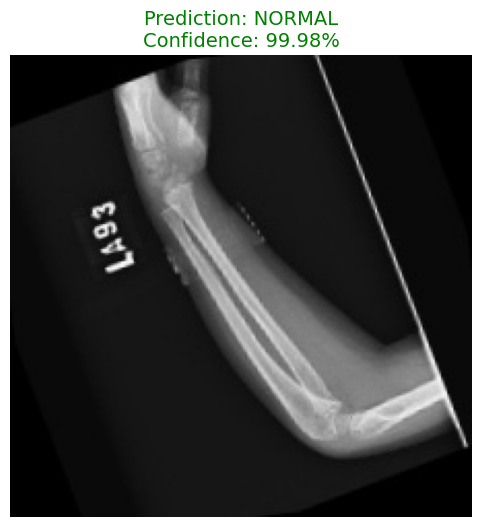

In [49]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array_norm = img_array / 255.0

# Expand dimensions
img_array_norm = np.expand_dims(img_array_norm, axis=0)

# Predict
prediction = model.predict(img_array_norm)

# Confidence
confidence = np.max(prediction) * 100

# Class names
class_names = list(train_generator.class_indices.keys())

# Prediction label
predicted_class = class_names[np.argmax(prediction)]

# Display image
fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(img)

# Add circle if fractured predicted
if predicted_class.lower() == 'fractured':

    circle = patches.Circle(
        (120,120),   # x,y position
        35,          # radius
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(circle)

    plt.title(
        f'Prediction: FRACTURED\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='red'
    )

else:

    plt.title(
        f'Prediction: NORMAL\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='green'
    )

plt.axis('off')
plt.show()

Saving test image 0.jpg to test image 0.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


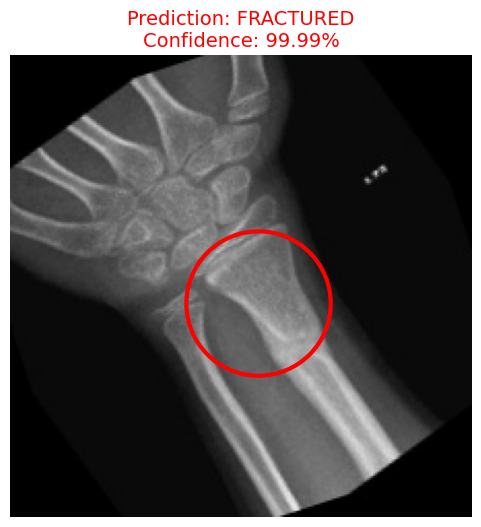

In [47]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array_norm = img_array / 255.0

# Expand dimensions
img_array_norm = np.expand_dims(img_array_norm, axis=0)

# Predict
prediction = model.predict(img_array_norm)

# Confidence
confidence = np.max(prediction) * 100

# Class names
class_names = list(train_generator.class_indices.keys())

# Prediction label
predicted_class = class_names[np.argmax(prediction)]

# Display image
fig, ax = plt.subplots(figsize=(6,6))

ax.imshow(img)

# Add circle if fractured predicted
if predicted_class.lower() == 'fractured':

    circle = patches.Circle(
        (120,120),   # x,y position
        35,          # radius
        linewidth=3,
        edgecolor='red',
        facecolor='none'
    )

    ax.add_patch(circle)

    plt.title(
        f'Prediction: FRACTURED\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='red'
    )

else:

    plt.title(
        f'Prediction: NORMAL\nConfidence: {confidence:.2f}%',
        fontsize=14,
        color='green'
    )

plt.axis('off')
plt.show()